In [21]:
import numpy as np
import matplotlib.pyplot as plt
from auditoryforage.utils import open_pickle_file, find_recent_epoch
no_seeds = 5
folder_name = './store/comparison/'
pattern = f'across_penalty_#seeds_{no_seeds}_#epochs_'
start_model_no = 0
epoch_increments_saved = 20
max_epoch_val = find_recent_epoch(directory = folder_name, pattern = pattern)
num_models = int(max_epoch_val/epoch_increments_saved)

def setup_matrix_across_epochs(start_model_no, num_models, measure, seed_index = 0):
    # rows are different epochs.
    # cols are corresp. different exp no.

    epochs_list =  [(elt + 1) * epoch_increments_saved for elt in range(start_model_no, num_models)]
    matrix_across_epochs = []
    for epoch in epochs_list:
        file_name = folder_name + f'across_penalty_#seeds_5_#epochs_{epoch}.pkl'
        detection_measures = open_pickle_file(file_name)
        matrix_across_epochs.append([curr_elt[seed_index]/detection_measures['input']['no_episodes'] for curr_elt in detection_measures['output'][measure]])
    matrix_across_epochs = np.array(matrix_across_epochs)
    food_reward_list = detection_measures['input']['food_reward_list']
    return epochs_list, food_reward_list, matrix_across_epochs

def extract_info_per_seed(seed_index):
    epochs_list, food_reward_list, total_reward_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'total_reward_list_across_exps',seed_index)
    best_epoch_list = np.argmax(total_reward_matrix,0)
    _, _, hit_count_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'hit_count_list',seed_index)
    _, _, miss_count_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'miss_count_list', seed_index)
    _, _, false_alarm_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'false_alarm_list', seed_index)
    return epochs_list, best_epoch_list, food_reward_list, total_reward_matrix, hit_count_matrix, miss_count_matrix, false_alarm_matrix

def visualize_per_seed_index(seed_index):
    epochs_list, best_epoch_list, food_reward_list, total_reward_matrix, hit_count_matrix, miss_count_matrix, false_alarm_matrix = extract_info_per_seed(seed_index)
    
    plt.figure()
    plt.plot(food_reward_list, [hit_count_matrix[epoch_ind][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))],'g*-')
    plt.plot(food_reward_list, [miss_count_matrix[epoch_ind][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))],'b*-')
    plt.plot(food_reward_list, [false_alarm_matrix[epoch_ind][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))],'r*-')
    plt.legend(['hit', 'miss', 'false alarm'])
    plt.xlabel('food reward')
    plt.ylabel('measure per trial')
    plt.title('Performance of best epochs')
    plt.show()

    plt.figure()
    plt.plot(food_reward_list, [total_reward_matrix[epoch_ind][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))],'*-')
    plt.xlabel('food reward')
    plt.ylabel('reward per trial')
    plt.title('Rewards per trial for best epochs')
    plt.show()

    plt.figure()
    plt.stem(food_reward_list, [epochs_list[best_ind] for best_ind in best_epoch_list])
    plt.xlabel('food reward')
    plt.ylabel('best epoch')
    plt.title('Best epoch for each penalty cost')
    plt.show()

    plt.figure()
    for penalty_ind in range(len(food_reward_list)):
        plt.plot(epochs_list, [total_reward_matrix[epoch_ind][penalty_ind] for epoch_ind in range(len(epochs_list))],'*-')
    plt.legend(food_reward_list)
    plt.xlabel('epoch number')
    plt.ylabel('rewards per trial')
    plt.title('Change in rewards per trial across epochs')
    plt.show()


best_seed_list = detection_measures['output']['best_seed_list']
setup_matrix_across_epochs(start_model_no, num_models, measure, seed_index = 0)
def extract_info_across_seeds():
    for seed_index in range(no_seeds):
        epochs_list, food_reward_list, total_reward_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'total_reward_list_across_exps',seed_index)
        best_epoch_list = np.argmax(total_reward_matrix,0)
        _, _, hit_count_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'hit_count_list',seed_index)
        _, _, miss_count_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'miss_count_list', seed_index)
        _, _, false_alarm_matrix = setup_matrix_across_epochs(start_model_no, num_models, 'false_alarm_list', seed_index)
    return epochs_list, best_epoch_list, food_reward_list, total_reward_matrix, hit_count_matrix, miss_count_matrix, false_alarm_matrix

Highest epoch saved is 220


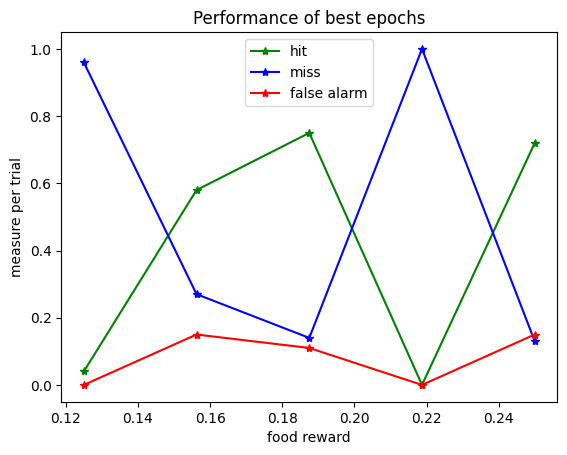

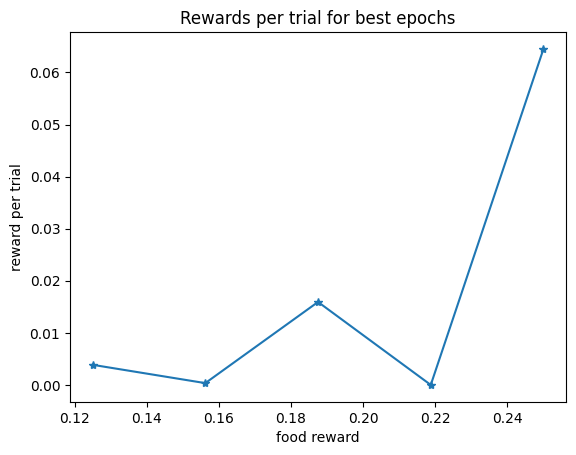

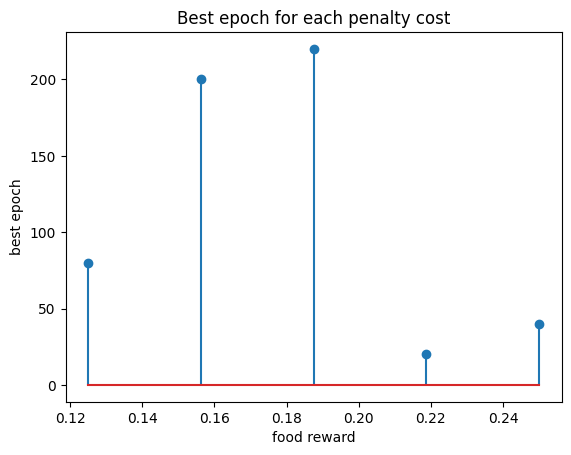

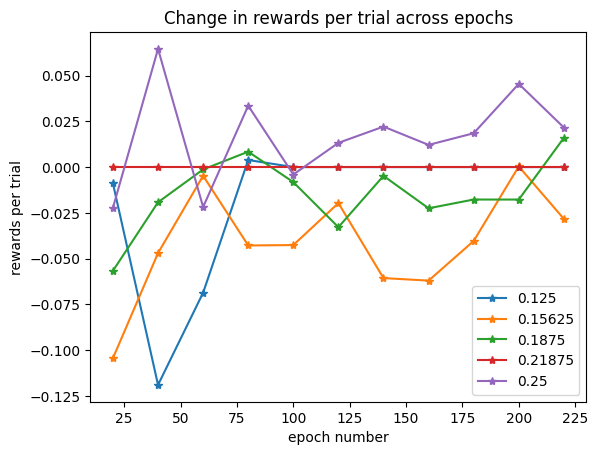

In [22]:
visualize_per_seed_index(seed_index= 0)

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from auditoryforage.utils import open_pickle_file, find_recent_epoch
no_seeds = 5
folder_name = './store/comparison/'
pattern = f'across_penalty_#seeds_{no_seeds}_#epochs_'
start_model_no = 0
epoch_increments_saved = 20
max_epoch_val = find_recent_epoch(directory = folder_name, pattern = pattern)
num_models = int(max_epoch_val/epoch_increments_saved)

def setup_measure_matrix(start_model_no, num_models, measure, no_seeds):
    # In general
        # dim 0 different epochs.
        # dim 1 is seed
        # dim 2 different exp no.
    # For best_seed_list
        # dim 0 different epochs.
        # dim 1 different exp no.

    epochs_list =  [(elt + 1) * epoch_increments_saved for elt in range(start_model_no, num_models)]
    measure_matrix = []
    for epoch in epochs_list:
        file_name = folder_name + f'across_penalty_#seeds_{no_seeds}_#epochs_{epoch}.pkl'
        detection_measures = open_pickle_file(file_name)
        if measure == 'best_seed_list':
            measure_matrix.append([curr_elt for curr_elt in detection_measures['output'][measure]])
        else:
            measure_matrix.append([])
            for seed_index in range(no_seeds):
                measure_matrix[-1].append([curr_elt[seed_index]/detection_measures['input']['no_episodes'] for curr_elt in detection_measures['output'][measure]])
    measure_matrix = np.array(measure_matrix)
    food_reward_list = detection_measures['input']['food_reward_list']
    return epochs_list, food_reward_list, measure_matrix

def extract_info_across_seeds(no_seeds):
    # For best_seed_list
    # dim 0 different exp no.
    # dim 1 (epoch_ind, seed_ind).

    across_seeds_dict = {}
    across_seeds_dict['epochs_list'], across_seeds_dict['food_reward_list'], across_seeds_dict['total_reward_matrix'] = setup_measure_matrix(start_model_no, num_models, 'total_reward_list_across_exps', no_seeds)
    _, _, across_seeds_dict['hit_count_matrix'] = setup_measure_matrix(start_model_no, num_models, 'hit_count_list', no_seeds)
    _, _, across_seeds_dict['miss_count_matrix'] = setup_measure_matrix(start_model_no, num_models, 'miss_count_list', no_seeds)
    _, _, across_seeds_dict['false_alarm_matrix'] = setup_measure_matrix(start_model_no, num_models, 'false_alarm_list', no_seeds)
    _, _, across_seeds_dict['best_seed_matrix'] = setup_measure_matrix(start_model_no, num_models, 'best_seed_list', no_seeds)
    
    max_total_rewards = np.max(across_seeds_dict['total_reward_matrix'], axis=(0, 1))
    best_epoch_seed_inds = [np.where(across_seeds_dict['total_reward_matrix'][:,:,exp_ind] == max_total_rewards[exp_ind]) for exp_ind in range(len(max_total_rewards))]
    across_seeds_dict['best_epoch_seed_inds'] = [(elt[0][0], elt[1][0]) for elt in best_epoch_seed_inds]

    return across_seeds_dict

def visualize_output(no_seeds):
    across_seeds_dict = extract_info_across_seeds(no_seeds)
    hit_count_matrix = across_seeds_dict['hit_count_matrix']
    miss_count_matrix = across_seeds_dict['miss_count_matrix']
    false_alarm_matrix = across_seeds_dict['false_alarm_matrix']
    best_epoch_seed_inds = across_seeds_dict['best_epoch_seed_inds']
    food_reward_list = across_seeds_dict['food_reward_list']
    
    def plot_hit_miss_FA(x_axis_list, hit_count_list, miss_count_list, false_alarm_list):
        plt.figure()
        plt.plot(x_axis_list, hit_count_list, '-*g')
        plt.plot(x_axis_list, miss_count_list, '-*b')
        plt.plot(x_axis_list, false_alarm_list, '-*r')
        plt.legend(['hit', 'miss', 'false alarm'])
        plt.xlabel('food reward') if x_axis_list == food_reward_list else plt.xlabel('epochs')
        plt.show()
    
    def plot_best_case():
        hit_count_list = [hit_count_matrix[best_epoch_seed_inds[exp_ind][0], best_epoch_seed_inds[exp_ind][1], exp_ind] for exp_ind in range(len(food_reward_list))]
        miss_count_list = [miss_count_matrix[best_epoch_seed_inds[exp_ind][0], best_epoch_seed_inds[exp_ind][1], exp_ind] for exp_ind in range(len(food_reward_list))]
        false_alarm_list = [false_alarm_matrix[best_epoch_seed_inds[exp_ind][0], best_epoch_seed_inds[exp_ind][1], exp_ind] for exp_ind in range(len(food_reward_list))]
        plot_hit_miss_FA(food_reward_list, hit_count_list, miss_count_list, false_alarm_list)

    
    plot_best_case()

Highest epoch saved is 440


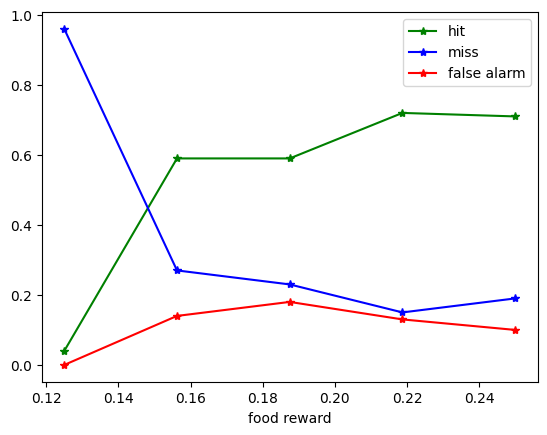

In [56]:
across_seeds_dict = visualize_output(5)